# LC-MS/MS Calibrator Purity Analysis

Proteomics-based purity assessment of two bovine NfL (bNfL) calibrator products:  
**bNfL, Progen** (NfL_1) and **bNfL, MyBioSource** (NfL_2).

Each calibrator was digested and analysed by LC-MS/MS (MaxQuant). Protein-level 
intensities are summed per experiment and expressed as a percentage of the dominant 
signal (NEFL). Contaminant species - principally NfH (NEFH), NfM (NEFM), GFAP, 
and β-tubulin isoforms - are quantified relative to NEFL to assess calibrator purity 
and inform concentration correction.

Source data: `MQevidenceTable.csv`  
Outputs: `fig_msms_purity_bNfL_Progen.svg`, `fig_msms_purity_bNfL_MyBioSource.svg`

## Setup

Global imports and rcParams. Font, size, and line-weight conventions match 
the rest of the NfL-iPLA paper figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Global rcParams ────────────────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth']     = 0.6

# ── Okabe-Ito palette ──────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

# ── NEFL highlight colours — matched to calibrator assignments in paper ────
# Non-NEFL proteins: black throughout (consistent with figure convention)
NEFL_COLOURS = {
    'NfL_1': okabe_ito['reddish purple'],   # bNfL, Progen
    'NfL_2': okabe_ito['sky blue'],     # bNfL, MyBioSource
}
COLOUR_OTHER = okabe_ito['black']

## Data loading and preprocessing

MaxQuant `evidence.txt` outputs from multiple experiments were concatenated and assigned gene_ids using gProfiler implemented in the Proetomics package RBPSuite https://github.com/jeffsmith8/RBPsuite. This produced `MQevidenceTable.csv`.

Protein-level intensities are summed across peptides within each experiment 
and normalised to the maximum intensity (NEFL), yielding **% NEFL intensity**.  
Proteins below 1% of the NEFL signal are excluded from plots.

In [2]:
MQ_evidenceTable = pd.read_csv('MQevidenceTable.csv')

print(f"Rows: {len(MQ_evidenceTable):,}")
print(f"Experiments detected: {sorted(MQ_evidenceTable['Experiment'].unique().tolist())}")
MQ_evidenceTable.head(2)

Rows: 5,651
Experiments detected: ['NfL_1', 'NfL_2', 'NfL_3', 'NfL_4', 'NfL_5']


,Unnamed: 0,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Acetyl (Protein N-term),Oxidation (M),Missed cleavages,...,Best MS/MS,Oxidation (M) site IDs,Taxonomy IDs,Query,ENTREZGENE_gPro all,ENTREZGENE_gPro primary,ENTREZGENE_gPro name,Gene names,Protein names,species
0,0,AAAAQLSLTQLSSGNPLYEK,20,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAQLSLTQLSSGNPLYEK_,NaN,NaN,1,0,0,...,0,NaN,NaN,A5D7I1,EPS15,EPS15,epidermal growth factor receptor pathway subst...,NaN,NaN,bovine
1,1,AAAAQLSLTQLSSGNPLYEK,20,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAQLSLTQLSSGNPLYEK_,NaN,NaN,1,0,0,...,1,NaN,NaN,A5D7I1,EPS15,EPS15,epidermal growth factor receptor pathway subst...,NaN,NaN,bovine


In [3]:
# Sum intensities per protein per experiment
sum_intensity_protein = MQ_evidenceTable.groupby(
    ['Experiment', 'species', 'ENTREZGENE_gPro primary', 'ENTREZGENE_gPro name'],
    as_index=False
)['Intensity'].sum()

sum_intensity_protein['Log2(sum intensity)'] = np.where(
    sum_intensity_protein['Intensity'] > 0,
    np.log2(sum_intensity_protein['Intensity']),
    0
)

# Normalise to NEFL (max intensity) within each experiment
sum_intensity_protein_dict = {}

for exp in sum_intensity_protein['Experiment'].unique():
    df = sum_intensity_protein[sum_intensity_protein['Experiment'] == exp].copy()
    df['% NEFL Intensity'] = (df['Intensity'] / df['Intensity'].max()) * 100
    sum_intensity_protein_dict[exp] = df

# Confirm NFL_1 and NFL_2 are present
for key in ['NfL_1', 'NfL_2']:
    if key in sum_intensity_protein_dict:
        n = (sum_intensity_protein_dict[key]['% NEFL Intensity'] > 1).sum()
        print(f"  {key}: {n} proteins above 1% threshold")
    else:
        print(f"  WARNING: {key} not found in data")

  NfL_1: 7 proteins above 1% threshold
  NfL_2: 7 proteins above 1% threshold


## Plot function

`plot_protein_intensity_perc` draws a single standalone horizontal bar chart 
for one calibrator. Each call produces one SVG.

Design decisions:
- **NEFL bar** is highlighted in the calibrator's assigned Okabe-Ito colour, 
  matching the colour used for that calibrator in the dilution curve figures.
- **All other proteins** use black — consistent with non-highlighted elements 
  elsewhere in the paper.
- Proteins with **< 1% NEFL intensity** are excluded.
- In-plot label format: `bNfL, Progen` / `bNfL, MyBioSource` — full supplier 
  name, no truncation, comma-separated from the analyte prefix.
- Figure width: 88 mm (single column). Height scales with number of proteins plotted.

In [4]:
def plot_protein_intensity_perc(dataframe, exp_key, heading, save=True):
    """
    Standalone horizontal bar plot of % NEFL intensity for one calibrator.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Slice for one experiment. Must contain '% NEFL Intensity' and
        'ENTREZGENE_gPro primary'.
    exp_key : str
        Experiment key (e.g. 'NFL_1', 'NFL_2') — used to look up NEFL
        highlight colour from NEFL_COLOURS.
    heading : str
        In-plot annotation label (e.g. 'bNfL, Progen').
    save : bool
        If True, saves SVG to current directory.
    """
    if '% NEFL Intensity' not in dataframe.columns:
        raise ValueError("'% NEFL Intensity' not found in dataframe columns")

    # ── Filter and sort ────────────────────────────────────────────────────
    df = (
        dataframe[dataframe['% NEFL Intensity'] > 1]
        .copy()
        .sort_values('% NEFL Intensity', ascending=True)
    )

    genes  = df['ENTREZGENE_gPro primary'].tolist()
    values = df['% NEFL Intensity'].tolist()
    n_bars = len(genes)

    # ── Colours ────────────────────────────────────────────────────────────
    colour_nefl = NEFL_COLOURS.get(exp_key, okabe_ito['orange'])  # fallback orange
    colours     = [colour_nefl if g == 'NEFL' else COLOUR_OTHER for g in genes]

    # ── Figure ─────────────────────────────────────────────────────────────
    fig_h = max(40, n_bars * 4) / 25.4   # ~4 mm per bar, min 40 mm
    fig_w = 88 / 25.4                    # single-column width
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    y_pos = np.arange(n_bars)

    ax.barh(
        y_pos, values,
        color=colours,
        alpha=0.6,
        linewidth=0,
        height=0.65,
    )

    # ── Axes ───────────────────────────────────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(genes)
    ax.set_xlabel('% total protein intensity')

#     x_max   = max(int(df['% NEFL Intensity'].max()), 10)
#     x_ticks = range(0, x_max + 11, 10)
    x_ticks = range(0, 101, 10)  # fixed 0–100%
    ax.set_xticks(x_ticks)
    ax.set_xlim(0, 100)
    ax.set_xticks(x_ticks)

    ax.grid(True, which='both', axis='x',
            linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── In-plot label ──────────────────────────────────────────────────────
    ax.text(
        0.98, 0.02, heading,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=6,
    )

    plt.tight_layout()

    if save:
        safe   = heading.replace(', ', '_').replace(' ', '_')
        fname  = f'fig_msms_purity_{safe}.svg'
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"Saved: {fname}")

    plt.show()

## Generate figures

One standalone SVG per calibrator.

Saved: fig_msms_purity_bNfL_Progen.svg


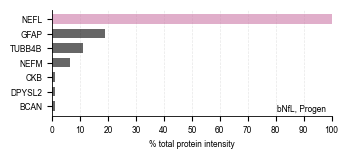

Saved: fig_msms_purity_bNfL_MyBioSource.svg


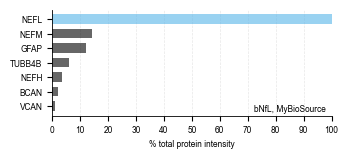

In [5]:
# Define experiment keys, labels, and output filenames
experiments = [
    ('NfL_1', 'bNfL, Progen'),
    ('NfL_2', 'bNfL, MyBioSource'),
]

for exp_key, label in experiments:
    if exp_key not in sum_intensity_protein_dict:
        print(f"Skipping {exp_key} — not found in data")
        continue
    plot_protein_intensity_perc(
        dataframe = sum_intensity_protein_dict[exp_key],
        exp_key   = exp_key,
        heading   = label,
        save      = True,
    )